In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
reports_dir = Path("../reports")

trades_path = reports_dir / "economic_backtest_trades_DK2.csv"

df = pd.read_csv(trades_path)

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())

df.head()

Rows: 5376
Date range: 2025-02-13 06:00:00 → 2025-09-25 05:00:00


,HourUTC,HourDK,SpotPriceEUR,target_24h_ahead,pred_xgboost_24h,fold,pred_current_price_baseline,expected_spread,realized_spread,signal,pnl_eur,cumulative_pnl_eur
0,2025-02-13 06:00:00,2025-02-13 07:00:00,190.330002,229.089996,151.74309,1,190.330002,-38.586912,38.759994,-1,-38.759994,-38.759994
1,2025-02-13 07:00:00,2025-02-13 08:00:00,222.380005,265.649994,166.08397,1,222.380005,-56.296035,43.269989,-1,-43.269989,-82.029983
2,2025-02-13 08:00:00,2025-02-13 09:00:00,218.059998,215.110001,151.06252,1,218.059998,-66.997478,-2.949997,-1,2.949997,-79.079986
3,2025-02-13 09:00:00,2025-02-13 10:00:00,201.910004,181.029999,165.09258,1,201.910004,-36.817424,-20.880005,-1,20.880005,-58.199981
4,2025-02-13 10:00:00,2025-02-13 11:00:00,182.570007,163.009995,184.02840,1,182.570007,1.458393,-19.560012,0,-0.000000,-58.199981


In [7]:
df["date"] = df["HourUTC"].dt.date

df[["HourUTC", "date", "signal", "pnl_eur"]].head()

,HourUTC,date,signal,pnl_eur
0,2025-02-13 06:00:00,2025-02-13,-1,-38.759994
1,2025-02-13 07:00:00,2025-02-13,-1,-43.269989
2,2025-02-13 08:00:00,2025-02-13,-1,2.949997
3,2025-02-13 09:00:00,2025-02-13,-1,20.880005
4,2025-02-13 10:00:00,2025-02-13,0,-0.000000


In [8]:
daily_pnl = (
    df.groupby("date")
    .agg(
        daily_pnl_eur=("pnl_eur", "sum"),
        n_trades=("signal", lambda x: (x != 0).sum())
    )
    .reset_index()
)

daily_pnl["cumulative_daily_pnl_eur"] = daily_pnl["daily_pnl_eur"].cumsum()

daily_pnl.head()

,date,daily_pnl_eur,n_trades,cumulative_daily_pnl_eur
0,2025-02-13,-355.389924,16,-355.389924
1,2025-02-14,1131.249941,24,775.860017
2,2025-02-15,54.400045,19,830.260062
3,2025-02-16,427.299971,19,1257.560033
4,2025-02-17,432.119964,18,1689.679997


In [9]:
total_pnl = df["pnl_eur"].sum()
avg_daily_pnl = daily_pnl["daily_pnl_eur"].mean()
std_daily_pnl = daily_pnl["daily_pnl_eur"].std()

best_day = daily_pnl["daily_pnl_eur"].max()
worst_day = daily_pnl["daily_pnl_eur"].min()

win_days_pct = (daily_pnl["daily_pnl_eur"] > 0).mean() * 100

risk_summary = pd.DataFrame([{
    "total_pnl_eur": round(total_pnl, 2),
    "avg_daily_pnl_eur": round(avg_daily_pnl, 2),
    "std_daily_pnl_eur": round(std_daily_pnl, 2),
    "best_day_eur": round(best_day, 2),
    "worst_day_eur": round(worst_day, 2),
    "win_days_pct": round(win_days_pct, 2),
}])

risk_summary

,total_pnl_eur,avg_daily_pnl_eur,std_daily_pnl_eur,best_day_eur,worst_day_eur,win_days_pct
0,94298.72,419.11,485.47,2716.9,-720.76,84.44


In [11]:
df["running_max_pnl"] = df["cumulative_pnl_eur"].cummax()
df["drawdown_eur"] = df["cumulative_pnl_eur"] - df["running_max_pnl"]

max_drawdown = df["drawdown_eur"].min()

print("Max drawdown EUR:", round(max_drawdown, 2))

Max drawdown EUR: -793.74


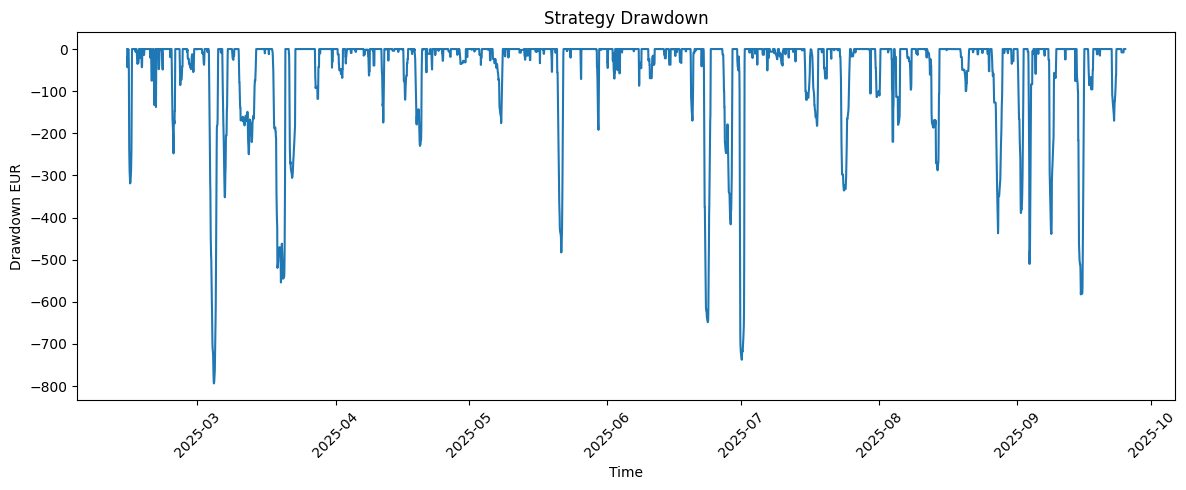

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(df["HourUTC"], df["drawdown_eur"])

plt.title("Strategy Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown EUR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
var_95 = np.percentile(daily_pnl["daily_pnl_eur"], 5)
var_99 = np.percentile(daily_pnl["daily_pnl_eur"], 1)

print("Daily VaR 95%:", round(var_95, 2), "EUR")
print("Daily VaR 99%:", round(var_99, 2), "EUR")

Daily VaR 95%: -167.86 EUR
Daily VaR 99%: -456.12 EUR


In [14]:
sharpe_ratio = (
    daily_pnl["daily_pnl_eur"].mean()
    / daily_pnl["daily_pnl_eur"].std()
    * np.sqrt(252)
)

print("Annualized Sharpe ratio:", round(sharpe_ratio, 2))

Annualized Sharpe ratio: 13.7


In [15]:
daily_loss_limit = -500  # EUR

df_risk = df.copy()

df_risk["risk_adjusted_signal"] = df_risk["signal"]
df_risk["risk_adjusted_pnl_eur"] = 0.0

for date, group in df_risk.groupby("date"):
    cumulative_day_pnl = 0.0
    
    for idx in group.index:
        if cumulative_day_pnl <= daily_loss_limit:
            df_risk.loc[idx, "risk_adjusted_signal"] = 0
            df_risk.loc[idx, "risk_adjusted_pnl_eur"] = 0.0
        else:
            pnl = df_risk.loc[idx, "pnl_eur"]
            df_risk.loc[idx, "risk_adjusted_pnl_eur"] = pnl
            cumulative_day_pnl += pnl

df_risk["risk_adjusted_cumulative_pnl_eur"] = df_risk["risk_adjusted_pnl_eur"].cumsum()

df_risk[[
    "HourUTC",
    "date",
    "signal",
    "risk_adjusted_signal",
    "pnl_eur",
    "risk_adjusted_pnl_eur",
]].head()

,HourUTC,date,signal,risk_adjusted_signal,pnl_eur,risk_adjusted_pnl_eur
0,2025-02-13 06:00:00,2025-02-13,-1,-1,-38.759994,-38.759994
1,2025-02-13 07:00:00,2025-02-13,-1,-1,-43.269989,-43.269989
2,2025-02-13 08:00:00,2025-02-13,-1,-1,2.949997,2.949997
3,2025-02-13 09:00:00,2025-02-13,-1,-1,20.880005,20.880005
4,2025-02-13 10:00:00,2025-02-13,0,0,-0.000000,-0.000000


In [24]:
original_total_pnl = df["pnl_eur"].sum()
risk_adjusted_total_pnl = df_risk["risk_adjusted_pnl_eur"].sum()

original_max_drawdown = df["drawdown_eur"].min()

df_risk["running_max_risk_pnl"] = df_risk["risk_adjusted_cumulative_pnl_eur"].cummax()
df_risk["risk_adjusted_drawdown_eur"] = (
    df_risk["risk_adjusted_cumulative_pnl_eur"] 
    - df_risk["running_max_risk_pnl"]
)

risk_adjusted_max_drawdown = df_risk["risk_adjusted_drawdown_eur"].min()

risk_control_summary = pd.DataFrame([
    {
        "strategy": "original",
        "daily_loss_limit_eur": 0,
        "risk_control_applied": False,
        "total_pnl_eur": round(original_total_pnl, 2),
        "max_drawdown_eur": round(original_max_drawdown, 2),
    },
    {
        "strategy": "daily_loss_limit",
        "daily_loss_limit_eur": daily_loss_limit,
        "risk_control_applied": True,
        "total_pnl_eur": round(risk_adjusted_total_pnl, 2),
        "max_drawdown_eur": round(risk_adjusted_max_drawdown, 2),
    }
])

risk_control_summary

,strategy,daily_loss_limit_eur,risk_control_applied,total_pnl_eur,max_drawdown_eur
0,original,0,False,94298.72,-793.74
1,daily_loss_limit,-500,True,94432.16,-793.74


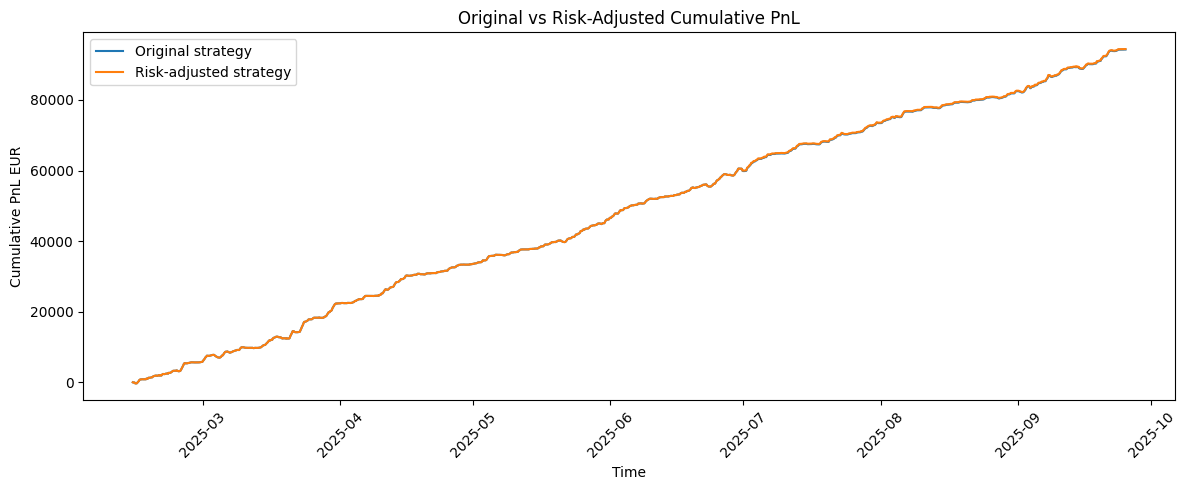

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["HourUTC"],
    df["cumulative_pnl_eur"],
    label="Original strategy"
)

plt.plot(
    df_risk["HourUTC"],
    df_risk["risk_adjusted_cumulative_pnl_eur"],
    label="Risk-adjusted strategy"
)

plt.title("Original vs Risk-Adjusted Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL EUR")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
risk_summary.to_csv(
    reports_dir / "risk_summary_DK2.csv",
    index=False
)

risk_control_summary.to_csv(
    reports_dir / "risk_control_summary_DK2.csv",
    index=False
)

daily_pnl.to_csv(
    reports_dir / "daily_pnl_DK2.csv",
    index=False
)

df_risk.to_csv(
    reports_dir / "risk_adjusted_trades_DK2.csv",
    index=False
)

print("Saved risk management reports.")

Saved risk management reports.
